# Active individuals per polity, per century

Nine century snapshots (3 × 3 grid) of polity-level activity. For each century `[c, c+99]`:

1. Count individuals from `individuals_cliopatria` whose `[floruit_period_start, floruit_period_end]` overlaps the century, exploded across semicolon-joined `polity_id`s.
2. Pick the polygon from `polities_periods_cliopatria` whose period midpoint is closest to `c+50` and overlaps the century — so polygons follow each polity's territorial shifts.
3. Color = `log10(count + 1)`, shared scale per figure.

Two figures: **all individuals** and **scientists** (`consolidated_database.is_scientist = 1`).

In [ ]:
import json
import sqlite3
from collections import defaultdict
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd  # GeoDataFrame construction needs pandas-style records
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from shapely.geometry import shape
from tqdm.auto import tqdm

ROOT = Path('/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database')
DB = ROOT / 'data' / 'humans_clean.sqlite3'
BASEMAP = ROOT / 'data' / 'ne_110m_admin_0_countries.geojson'
OUT_DIR = ROOT / 'notebooks' / 'use_cases' / 'polity_century_maps'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 9 evenly spaced centuries spanning the era with strong coverage
CENTURIES = [-400, -100, 200, 500, 800, 1100, 1400, 1700, 1900]
CMAP = 'magma'

## 1. Load individual×polity rows with floruit windows

In [ ]:
with sqlite3.connect(DB) as conn:
    df = pl.read_database(
        '''
        SELECT
            ic.wikidata_id,
            ic.polity_id,
            ic.floruit_period_start AS start,
            ic.floruit_period_end   AS end,
            COALESCE(cd.is_scientist, 0) AS is_scientist
        FROM individuals_cliopatria ic
        LEFT JOIN consolidated_database cd USING (wikidata_id)
        WHERE ic.floruit_period_start IS NOT NULL
          AND ic.floruit_period_end   IS NOT NULL
          AND ic.polity_id IS NOT NULL
          AND ic.polity_id <> ''
        ''',
        conn,
    )
df = df.with_columns(pl.col('polity_id').str.split(';').alias('polity_ids')).drop('polity_id')
print(f'{df.height:,} individual×polity rows')
df.head()

## 2. Per-century counts (all + scientists)

In [ ]:
starts = df['start'].to_numpy()
ends = df['end'].to_numpy()
is_sci = df['is_scientist'].to_numpy()
polity_lists = df['polity_ids'].to_list()

all_counts = {c: defaultdict(int) for c in CENTURIES}
sci_counts = {c: defaultdict(int) for c in CENTURIES}

for c in tqdm(CENTURIES, desc='centuries'):
    c_lo, c_hi = c, c + 99
    idx = np.flatnonzero((starts <= c_hi) & (ends >= c_lo))
    for i in idx:
        sci_flag = is_sci[i]
        for pid_str in polity_lists[i]:
            try:
                pid = int(pid_str)
            except (TypeError, ValueError):
                continue
            all_counts[c][pid] += 1
            if sci_flag:
                sci_counts[c][pid] += 1

pl.DataFrame({
    'century': CENTURIES,
    'polities_all':   [len(all_counts[c]) for c in CENTURIES],
    'individuals':    [sum(all_counts[c].values()) for c in CENTURIES],
    'polities_sci':   [len(sci_counts[c]) for c in CENTURIES],
    'scientists':     [sum(sci_counts[c].values()) for c in CENTURIES],
})

## 3. Pick the representative polygon per polity per century

In [ ]:
with sqlite3.connect(DB) as conn:
    geom_df = pl.read_database(
        '''
        SELECT polity_id, polity_name, from_year, to_year, geometry
        FROM polities_periods_cliopatria
        ''',
        conn,
    )
geom_df = geom_df.with_columns(((pl.col('from_year') + pl.col('to_year')) / 2.0).alias('mid'))

geoms = {}
for c in tqdm(CENTURIES, desc='select geoms'):
    c_lo, c_hi, c_mid = c, c + 99, c + 50
    sub = (
        geom_df.filter((pl.col('from_year') <= c_hi) & (pl.col('to_year') >= c_lo))
        .with_columns((pl.col('mid') - c_mid).abs().alias('dist'))
        .sort('dist')
        .unique(subset=['polity_id'], keep='first', maintain_order=True)
    )
    century_map = {}
    for row in sub.iter_rows(named=True):
        try:
            g = shape(json.loads(row['geometry']))
        except Exception:
            continue
        century_map[int(row['polity_id'])] = {'name': row['polity_name'], 'geometry': g}
    geoms[c] = century_map

{c: len(v) for c, v in geoms.items()}

## 4. Render — 3×3 small multiples

In [5]:
basemap = gpd.read_file(BASEMAP) if BASEMAP.exists() else None

def render(counts, title, out_path):
    log_max = 1.0
    for c in CENTURIES:
        if counts[c]:
            log_max = max(log_max, np.log10(max(counts[c].values()) + 1))
    norm = Normalize(vmin=0, vmax=log_max)

    fig, axes = plt.subplots(3, 3, figsize=(15, 8))
    axes = axes.flatten()

    for ax, c in zip(axes, CENTURIES):
        if basemap is not None:
            basemap.boundary.plot(ax=ax, color='#cfcfcf', linewidth=0.3)
        century_counts = counts[c]
        century_geoms = geoms.get(c, {})
        rows = []
        for pid, cnt in century_counts.items():
            g = century_geoms.get(pid)
            if g is None:
                continue
            rows.append({'polity_id': pid, 'name': g['name'], 'count': cnt, 'geometry': g['geometry']})
        if rows:
            gdf = gpd.GeoDataFrame(rows, geometry='geometry', crs='EPSG:4326')
            gdf['log_count'] = np.log10(gdf['count'] + 1)
            gdf.plot(ax=ax, column='log_count', cmap=CMAP, norm=norm,
                     edgecolor='white', linewidth=0.25, alpha=0.92)
        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 85)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        label = f'{abs(c)} BCE' if c < 0 else f'{c} CE'
        ax.set_title(label, fontsize=11, pad=4)

    fig.suptitle(title, fontsize=14, y=0.995)
    cbar_ax = fig.add_axes([0.30, 0.045, 0.42, 0.014])
    sm = ScalarMappable(norm=norm, cmap=CMAP); sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('log10(active individuals + 1)', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    fig.tight_layout(rect=[0, 0.07, 1, 0.97])
    fig.savefig(out_path, dpi=170, bbox_inches='tight')
    plt.show()
    print(f'Saved {out_path}')

### All individuals

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_37079/982572729.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


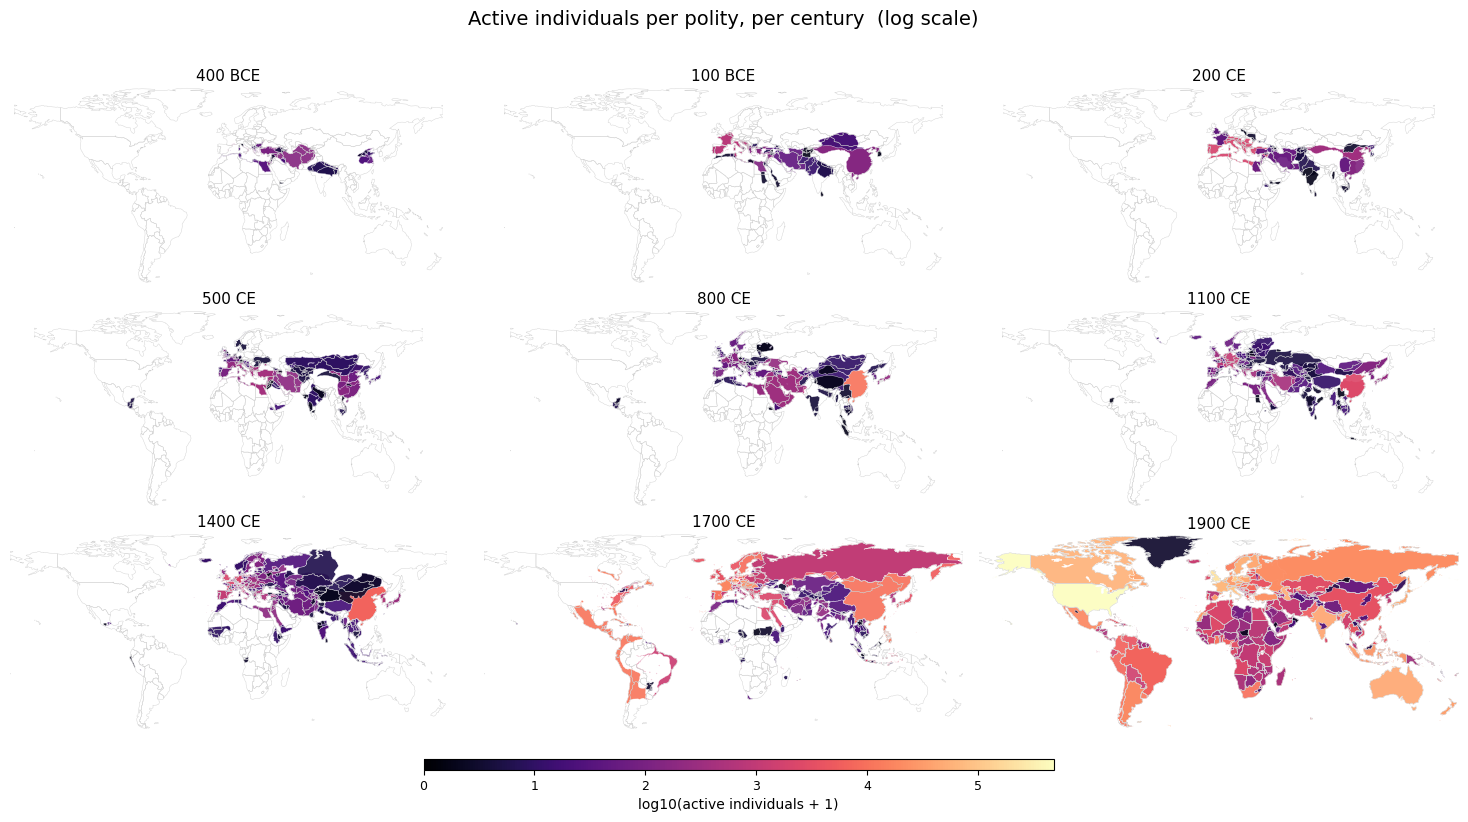

Saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/use_cases/polity_century_maps/active_individuals_per_polity_3x3.png


In [6]:
render(
    all_counts,
    title='Active individuals per polity, per century  (log scale)',
    out_path=OUT_DIR / 'active_individuals_per_polity_3x3.png',
)

### Scientists

/var/folders/lx/9b13r6ln63jb54_3xlf9b_380000gn/T/ipykernel_37079/982572729.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0.07, 1, 0.97])


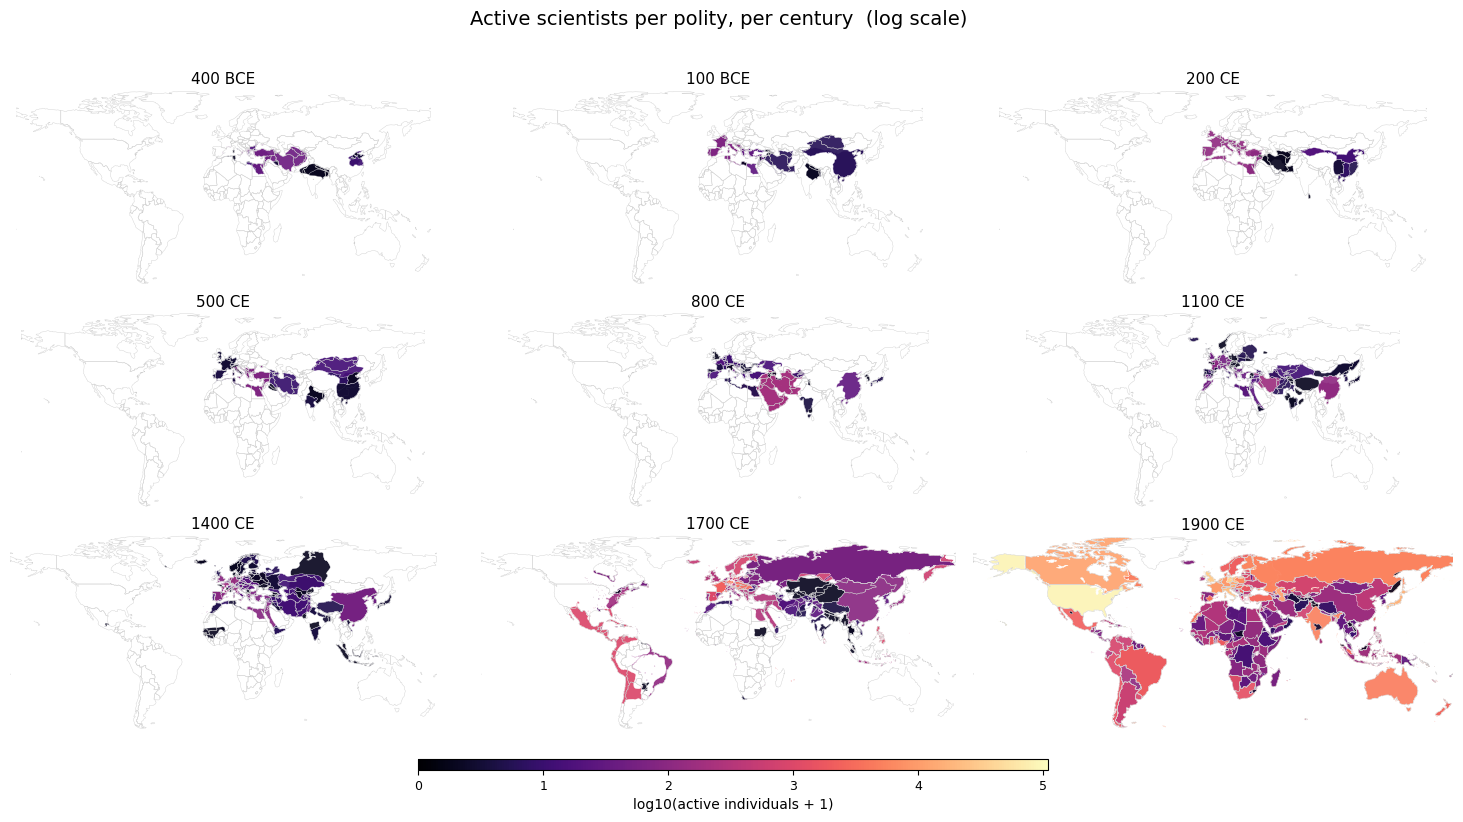

Saved /Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/notebooks/use_cases/polity_century_maps/active_scientists_per_polity_3x3.png


In [7]:
render(
    sci_counts,
    title='Active scientists per polity, per century  (log scale)',
    out_path=OUT_DIR / 'active_scientists_per_polity_3x3.png',
)